<a href="https://colab.research.google.com/github/reneta-dimitrova96/Deep-Learning-Course-Project-2026/blob/main/notebooks/01_data_preparation_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semantic Paraphrase Detection with Deep Learning

## Notebook Objective

This notebook covers the initial data loading, cleaning and exploratory data analysis (EDA) for the paraphrase detection project.

The analysis includes checking the dataset structure, missing values, class distribution, duplicate sentence pairs, sentence lengths and lexical overlap.

The project uses the **PAWS-Wiki Labeled (Final)** dataset. The PAWS-Wiki dataset was released by Google Research and is used in this project for educational purposes. Google LLC (Google) is acknowledged as the data source.

### Sources

- [PAWS-Wiki Dataset on Hugging Face](https://huggingface.co/datasets/google-research-datasets/paws)
- [Official PAWS Repository by Google Research](https://github.com/google-research-datasets/paws)
- [PAWS: Paraphrase Adversaries from Word Scrambling](https://arxiv.org/abs/1904.01130)

## 1. Setup and Imports

First, the required libraries are installed and imported.

In [1]:
!pip install -q datasets

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import re

## 2. Loading the Dataset

The PAWS-Wiki `labeled_final` configuration is loaded directly from the Hugging Face Hub using the `datasets` library.

In [3]:
dataset = load_dataset(
    "google-research-datasets/paws",
    "labeled_final"
)

README.md:   0%|          | 0.00/9.79k [00:00<?, ?B/s]

labeled_final/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 8.43MB            

labeled_final/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

labeled_final/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 1.24MB            

labeled_final/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

labeled_final/validation-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B / 1.23MB            

labeled_final/validation-00000-of-00001.(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/49401 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8000 [00:00<?, ? examples/s]

## 3. Dataset Structure

The dataset is inspected to verify the available splits, features, and number of examples.

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 49401
    })
    test: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['id', 'sentence1', 'sentence2', 'label'],
        num_rows: 8000
    })
})


### Example Observation

A single training example is displayed to inspect the structure of a sentence pair and its corresponding label.

In [ ]:
dataset["train"][0]

{'id': 1,
 'sentence1': 'In Paris , in October 1560 , he secretly met the English ambassador , Nicolas Throckmorton , asking him for a passport to return to England through Scotland .',
 'sentence2': 'In October 1560 , he secretly met with the English ambassador , Nicolas Throckmorton , in Paris , and asked him for a passport to return to Scotland through England .',
 'label': 0}

### Dataset Features

The available columns in the training split are inspected.

In [ ]:
dataset["train"].column_names

['id', 'sentence1', 'sentence2', 'label']

## 4. Converting the Training Split to a DataFrame

For easier exploratory analysis, the training split is converted to a Pandas DataFrame.

In [5]:
train_df = dataset["train"].to_pandas()

train_df.head()

,id,sentence1,sentence2,label
0,1,"In Paris , in October 1560 , he secretly met t...","In October 1560 , he secretly met with the Eng...",0
1,2,The NBA season of 1975 -- 76 was the 30th seas...,The 1975 -- 76 season of the National Basketba...,1
2,3,"There are also specific discussions , public p...","There are also public discussions , profile sp...",0
3,4,When comparable rates of flow can be maintaine...,The results are high when comparable flow rate...,1
4,5,It is the seat of Zerendi District in Akmola R...,It is the seat of the district of Zerendi in A...,1


### Dataset Size

The dimensions of the training dataset are checked.

In [6]:
train_df.shape

(49401, 4)

## 5. Data Quality Check

Missing values are checked to ensure that all sentence pairs and labels contain valid data before further analysis and model training.

In [7]:
train_df.isnull().sum()

,0
id,0
sentence1,0
sentence2,0
label,0


No missing values were found in the training dataset. Therefore, no rows need to be removed or filled at this stage.

## 6. Class Distribution

The distribution of the target labels is examined to determine whether the dataset is balanced between paraphrase and non-paraphrase examples.

In [ ]:
train_df["label"].value_counts()

,count
label,
0,27572
1,21829


In [ ]:
train_df["label"].value_counts(normalize=True) * 100

,proportion
label,
0,55.812635
1,44.187365


The training set contains:

- **27,572 non-paraphrase pairs (55.81%)**
- **21,829 paraphrase pairs (44.19%)**

The dataset is slightly imbalanced toward the non-paraphrase class, but the difference is relatively small. Both classes are sufficiently represented for model training.

### Duplicate Sentence Pairs

The training data is checked for duplicate sentence pairs to determine whether identical examples appear more than once in the dataset.

In [8]:
train_df.duplicated(subset=["sentence1", "sentence2"]).sum()

np.int64(52)

The training split contains 52 duplicated rows based on the combination of sentence1 and sentence2. Before removing them, the duplicates are inspected to determine whether they have consistent labels.

In [9]:
duplicate_pairs = train_df[
    train_df.duplicated(
        subset=["sentence1", "sentence2"],
        keep=False
    )
].sort_values(["sentence1", "sentence2"])

duplicate_pairs.head(10)

,id,sentence1,sentence2,label
12177,12178,A month later the Spanish fleet was destroyed ...,"A month later , the Spanish fleet was destroye...",1
35130,35131,A month later the Spanish fleet was destroyed ...,"A month later , the Spanish fleet was destroye...",1
7115,7116,"By the middle of the 7th century , alchemy was...",By the middle of the 7th century alchemy was e...,0
30673,30674,"By the middle of the 7th century , alchemy was...",By the middle of the 7th century alchemy was e...,1
11819,11820,By the middle of the 7th century alchemy was a...,"By the middle of the 7th century , alchemy was...",1
34239,34240,By the middle of the 7th century alchemy was a...,"By the middle of the 7th century , alchemy was...",0
25085,25086,Castlebrae Community High School is a secondar...,Castlebrae Community High School is a secondar...,0
43188,43189,Castlebrae Community High School is a secondar...,Castlebrae Community High School is a secondar...,1
6214,6215,Construction of the new stadium was held for 4...,The construction of the new stadium was held f...,1
14088,14089,Construction of the new stadium was held for 4...,The construction of the new stadium was held f...,1


In [10]:
conflicting_duplicates = (
    train_df
    .groupby(["sentence1", "sentence2"])["label"]
    .nunique()
    .gt(1)
    .sum()
)

conflicting_duplicates

np.int64(15)

The inspection revealed 15 duplicated sentence pairs with conflicting labels. Since identical inputs should not have contradictory target labels, these cases require further examination before preprocessing.

In [11]:
conflicting_pairs = (
    train_df
    .groupby(["sentence1", "sentence2"])["label"]
    .nunique()
    .reset_index()
)

conflicting_pairs = conflicting_pairs[
    conflicting_pairs["label"] > 1
]

conflicting_pairs.shape

(15, 3)

In [12]:
conflicting_rows = train_df.merge(
    conflicting_pairs[["sentence1", "sentence2"]],
    on=["sentence1", "sentence2"],
    how="inner"
)

conflicting_rows.shape

(30, 4)

In [13]:
conflicting_rows.sort_values(
    ["sentence1", "sentence2", "label"]
).head(20)

,id,sentence1,sentence2,label
5,7116,"By the middle of the 7th century , alchemy was...",By the middle of the 7th century alchemy was e...,0
18,30674,"By the middle of the 7th century , alchemy was...",By the middle of the 7th century alchemy was e...,1
20,34240,By the middle of the 7th century alchemy was a...,"By the middle of the 7th century , alchemy was...",0
7,11820,By the middle of the 7th century alchemy was a...,"By the middle of the 7th century , alchemy was...",1
14,25086,Castlebrae Community High School is a secondar...,Castlebrae Community High School is a secondar...,0
27,43189,Castlebrae Community High School is a secondar...,Castlebrae Community High School is a secondar...,1
25,42802,Dye rode in Mauritius after eight years in Hon...,"Dye rode after eight years in Hong Kong , Maur...",0
15,26140,Dye rode in Mauritius after eight years in Hon...,"Dye rode after eight years in Hong Kong , Maur...",1
11,20524,Jeppe Tengbjerg ( born 28 December 1973 ) is a...,"Jeppe Tengbjerg ( born December 28 , 1973 ) is...",0
2,2474,Jeppe Tengbjerg ( born 28 December 1973 ) is a...,"Jeppe Tengbjerg ( born December 28 , 1973 ) is...",1


The 15 conflicting sentence pairs correspond to 30 training rows. Each identical sentence pair appears with both possible labels, creating contradictory supervision for the model.

To avoid training on inconsistent targets, all rows belonging to these conflicting pairs are removed. Remaining duplicate pairs with consistent labels are reduced to a single example.

In [14]:
clean_train_df = train_df.merge(
    conflicting_pairs[["sentence1", "sentence2"]],
    on=["sentence1", "sentence2"],
    how="left",
    indicator=True
)

clean_train_df = clean_train_df[
    clean_train_df["_merge"] == "left_only"
].drop(columns="_merge")

In [15]:
clean_train_df.shape

(49371, 4)

The 30 rows associated with the 15 conflicting sentence pairs were removed from the training data. After this step, the dataset contains **49,371 rows**.

The remaining duplicated sentence pairs have consistent labels. These duplicates will be reduced to a single occurrence to avoid training the models repeatedly on identical examples.


In [16]:
clean_train_df = clean_train_df.drop_duplicates(
    subset=["sentence1", "sentence2"]
).reset_index(drop=True)

In [17]:
clean_train_df.shape

(49334, 4)

In [18]:
clean_train_df.duplicated(
    subset=["sentence1", "sentence2"]
).sum()

np.int64(0)

In [19]:
(
    clean_train_df
    .groupby(["sentence1", "sentence2"])["label"]
    .nunique()
    .gt(1)
    .sum()
)

np.int64(0)

After cleaning, the training set contains 49,334 unique sentence pairs. All duplicate pairs and conflicting labels have been removed, leaving a consistent training dataset for the subsequent modeling experiments.

In [21]:
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

### Data Leakage Check

The dataset splits are checked for overlapping sentence pairs to ensure that the same examples do not appear in both the training and evaluation data.

In [22]:
train_validation_overlap = clean_train_df.merge(
    validation_df[["sentence1", "sentence2"]],
    on=["sentence1", "sentence2"],
    how="inner"
)

train_validation_overlap.shape

(0, 4)

In [23]:
train_test_overlap = clean_train_df.merge(
    test_df[["sentence1", "sentence2"]],
    on=["sentence1", "sentence2"],
    how="inner"
)

train_test_overlap.shape

(0, 4)

In [24]:
validation_test_overlap = validation_df.merge(
    test_df[["sentence1", "sentence2"]],
    on=["sentence1", "sentence2"],
    how="inner"
)

validation_test_overlap.shape

(0, 4)

No overlapping sentence pairs were found between the training, validation, and test splits. This indicates that the evaluation data does not contain exact sentence-pair duplicates from the training data, reducing the risk of data leakage during model evaluation.


## 7. Sentence Length Analysis

The length of the sentences is analyzed to better understand the text distribution and to support later preprocessing decisions such as sequence padding and maximum input length.

In [25]:
clean_train_df["sentence1_length"] = clean_train_df["sentence1"].str.split().str.len()
clean_train_df["sentence2_length"] = clean_train_df["sentence2"].str.split().str.len()

In [26]:
clean_train_df[
    ["sentence1_length", "sentence2_length"]
].describe()

,sentence1_length,sentence2_length
count,49334.000000,49334.000000
mean,21.345016,21.341975
std,5.469049,5.453945
min,5.000000,2.000000
25%,17.000000,17.000000
50%,21.000000,21.000000
75%,26.000000,26.000000
max,37.000000,36.000000


The two sentence columns have very similar length distributions, with an average of approximately 21 words per sentence. Most sentences contain between 17 and 26 words, while the longest examples contain fewer than 40 words. This relatively compact sentence length distribution should make sequence preprocessing manageable for the later deep learning models.

### Sentence Length Distribution

The distributions of sentence lengths are visualized to compare the typical number of words in `sentence1` and `sentence2`.

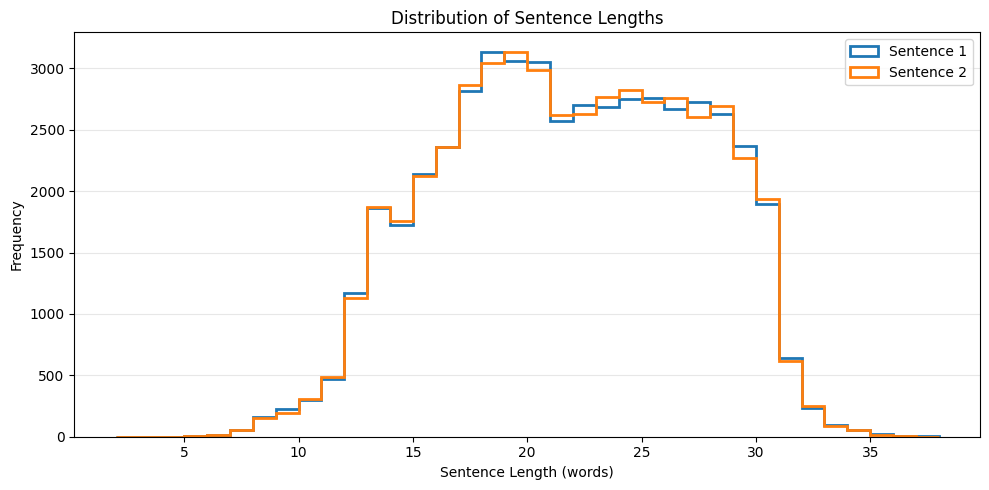

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_train_df["sentence1_length"],
    bins=range(2, 39),
    histtype="step",
    linewidth=2,
    label="Sentence 1"
)

plt.hist(
    clean_train_df["sentence2_length"],
    bins=range(2, 39),
    histtype="step",
    linewidth=2,
    label="Sentence 2"
)

plt.xlabel("Sentence Length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The visualization confirms that `sentence1` and `sentence2` have nearly identical length distributions, with the two curves closely overlapping across most of the range.

This suggests that there is no substantial difference in sentence length between the two positions in a pair, and neither sentence column is systematically longer than the other.


## 8. Example Sentence Pairs

Several examples from both target classes are inspected to better understand the paraphrase detection task and the types of sentence pairs contained in PAWS-Wiki.

In [28]:
paraphrase_examples = clean_train_df[
    clean_train_df["label"] == 1
][["sentence1", "sentence2", "label"]].sample(
    5,
    random_state=42
)

paraphrase_examples

,sentence1,sentence2,label
45092,Eugene Luening ( sometimes Eugen Luening ) ( 1...,Eugene Luening ( sometimes Eugen Luening ) ( 1...,1
42662,The Westlake Village neighborhood and the Vent...,The Westlake village neighborhood and the Vent...,1
31281,Her release was recognized by the suffragettes...,Her release was recognised by the suffragettes...,1
18286,"Margaret , however , refused to hand over the ...","However , Margaret refused to hand Hainaut ove...",1
40689,"In April 2016 , Malik Riaz Hussain 's son , Ah...","In April 2016 , the son of Malik Riaz Hussain ...",1


In [29]:
non_paraphrase_examples = clean_train_df[
    clean_train_df["label"] == 0
][["sentence1", "sentence2", "label"]].sample(
    5,
    random_state=42
)

non_paraphrase_examples

,sentence1,sentence2,label
13268,The childhood of Berkeley was spent in Coventr...,The childhood of Berkeley was spent in Warwick...,0
9690,It was expanded in 1910 from Laura to Wilmingt...,It was extended from Laura in 1910 to Booleroo...,0
20578,He studied philosophy in Graz and in Vienna an...,He studied philosophy in Vienna and Padua and ...,0
28347,A number of conditions can be put on a market ...,A number of conditions can be imposed on a mar...,0
35085,The river Pălăoaia is a tributary of the Muere...,The Muereasca River is a tributary of the Rive...,0


The examples show that high word overlap does not always imply the same meaning.

Paraphrase pairs preserve the underlying meaning despite structural changes, while non-paraphrase pairs may use very similar words but express different relationships.


## 9. Lexical Overlap Analysis

The lexical overlap between the two sentences is analyzed to examine how much vocabulary they share and whether high word similarity is sufficient to distinguish paraphrases from non-paraphrases.

### Lexical Overlap Function

A simple Jaccard similarity measure is used to calculate the lexical overlap between each pair of sentences.

The similarity is calculated as:

$$
J(A, B) = \frac{|A \cap B|}{|A \cup B|}
$$

where:

- $A$ is the set of unique words in the first sentence
- $B$ is the set of unique words in the second sentence
- $A \cap B$ represents the words shared by both sentences
- $A \cup B$ represents all unique words from both sentences

The result ranges from 0 to 1, where higher values indicate greater lexical overlap.

**Reference:** https://en.wikipedia.org/wiki/Jaccard_index

In [30]:
def lexical_overlap(sentence1, sentence2):
    words1 = set(re.findall(r"\b\w+\b", sentence1.lower()))
    words2 = set(re.findall(r"\b\w+\b", sentence2.lower()))

    return len(words1 & words2) / len(words1 | words2)

In [31]:
clean_train_df["lexical_overlap"] = clean_train_df.apply(
    lambda row: lexical_overlap(
        row["sentence1"],
        row["sentence2"]
    ),
    axis=1
)

In [32]:
clean_train_df[
    ["sentence1", "sentence2", "label", "lexical_overlap"]
].head()

,sentence1,sentence2,label,lexical_overlap
0,"In Paris , in October 1560 , he secretly met t...","In October 1560 , he secretly met with the Eng...",0,0.840000
1,The NBA season of 1975 -- 76 was the 30th seas...,The 1975 -- 76 season of the National Basketba...,1,1.000000
2,"There are also specific discussions , public p...","There are also public discussions , profile sp...",0,0.900000
3,When comparable rates of flow can be maintaine...,The results are high when comparable flow rate...,1,0.916667
4,It is the seat of Zerendi District in Akmola R...,It is the seat of the district of Zerendi in A...,1,1.000000


In [33]:
clean_train_df.groupby("label")["lexical_overlap"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,27550.0,0.892667,0.073223,0.0625,0.842105,0.888889,0.944444,1.0
1,21784.0,0.892599,0.062827,0.5000,0.846154,0.882353,0.933333,1.0


The two classes have almost identical average lexical overlap. This indicates that word overlap alone is not sufficient to distinguish paraphrases from non-paraphrases, since both classes often contain highly similar vocabulary.

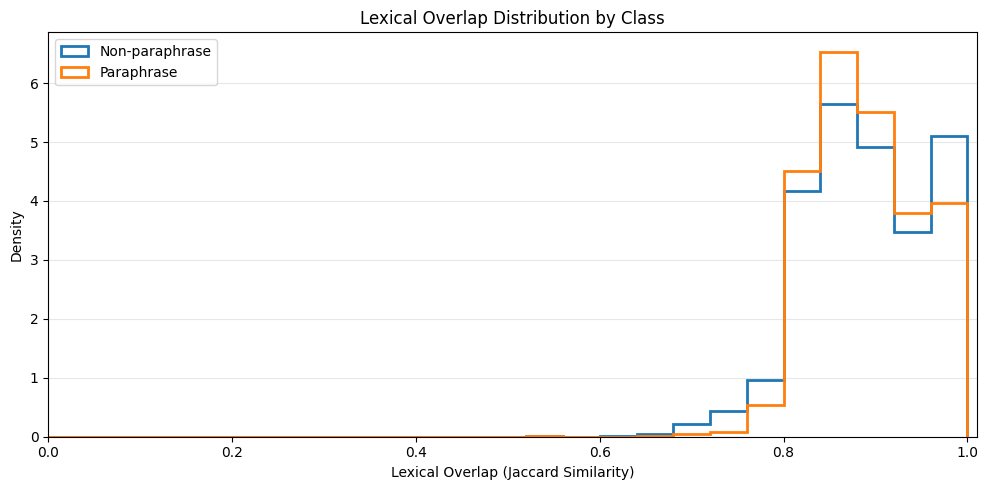

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_train_df.loc[
        clean_train_df["label"] == 0,
        "lexical_overlap"
    ],
    bins=25,
    range=(0, 1),
    density=True,
    histtype="step",
    linewidth=2,
    label="Non-paraphrase"
)

plt.hist(
    clean_train_df.loc[
        clean_train_df["label"] == 1,
        "lexical_overlap"
    ],
    bins=25,
    range=(0, 1),
    density=True,
    histtype="step",
    linewidth=2,
    label="Paraphrase"
)

plt.xlabel("Lexical Overlap (Jaccard Similarity)")
plt.ylabel("Density")
plt.title("Lexical Overlap Distribution by Class")
plt.xlim(0, 1.01)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The two classes overlap across much of the lexical similarity range, although their distributions are not identical. This suggests that lexical overlap may provide some useful information, but it is not sufficient on its own to clearly distinguish paraphrases from non-paraphrases.

## 10. Validation and Test Quality Check

The validation and test splits are checked for missing values, duplicate sentence pairs, and conflicting labels before they are used for model evaluation.

In [ ]:
for name, df in {
    "Validation": validation_df,
    "Test": test_df
}.items():

    print(f"{name} split")
    print("Missing values:")
    print(df.isnull().sum())

    print(
        "Duplicate pairs:",
        df.duplicated(subset=["sentence1", "sentence2"]).sum()
    )

    conflicting = (
        df
        .groupby(["sentence1", "sentence2"])["label"]
        .nunique()
        .gt(1)
        .sum()
    )

    print("Conflicting pairs:", conflicting)
    print()

Validation split
Missing values:
id           0
sentence1    0
sentence2    0
label        0
dtype: int64
Duplicate pairs: 6
Conflicting pairs: 0

Test split
Missing values:
id           0
sentence1    0
sentence2    0
label        0
dtype: int64
Duplicate pairs: 18
Conflicting pairs: 5



In [ ]:
test_conflicting_pairs = (
    test_df
    .groupby(["sentence1", "sentence2"])["label"]
    .nunique()
    .reset_index()
)

test_conflicting_pairs = test_conflicting_pairs[
    test_conflicting_pairs["label"] > 1
]

test_conflicting_pairs.shape

(5, 3)

In [ ]:
test_conflicting_rows = test_df.merge(
    test_conflicting_pairs[["sentence1", "sentence2"]],
    on=["sentence1", "sentence2"],
    how="inner"
)

test_conflicting_rows.shape

(10, 4)

In [ ]:
test_conflicting_rows.sort_values(
    ["sentence1", "sentence2", "label"]
)

,id,sentence1,sentence2,label
9,7200,It is present in Asia in Japan .,"In Asia , it is present in Japan .",0
4,2614,It is present in Asia in Japan .,"In Asia , it is present in Japan .",1
6,4474,It is present in Asia in Japan .,"In Japan , it is present in Asia .",0
7,4560,It is present in Asia in Japan .,"In Japan , it is present in Asia .",1
1,1816,The estimated mean income for a household in t...,The estimated middle income for a household in...,0
8,5379,The estimated mean income for a household in t...,The estimated middle income for a household in...,1
5,3923,This is a list of the international sporting e...,This is a list of international sporting event...,0
3,2471,This is a list of the international sporting e...,This is a list of international sporting event...,1
0,219,"To see about the background to these events , ...","To read about the background to these events ,...",0
2,2200,"To see about the background to these events , ...","To read about the background to these events ,...",1


The validation split contains a few duplicate sentence pairs with consistent labels, while the test split also contains five conflicting pairs with different labels. To keep the evaluation data consistent, cleaned copies of both splits are created by removing repeated examples and conflicting pairs.

In [ ]:
clean_validation_df = validation_df.drop_duplicates(
    subset=["sentence1", "sentence2"]
).reset_index(drop=True)

clean_validation_df.shape

(7994, 4)

In [ ]:
clean_test_df = test_df.merge(
    test_conflicting_pairs[["sentence1", "sentence2"]],
    on=["sentence1", "sentence2"],
    how="left",
    indicator=True
)

clean_test_df = clean_test_df[
    clean_test_df["_merge"] == "left_only"
].drop(columns="_merge")

In [ ]:
clean_test_df = clean_test_df.drop_duplicates(
    subset=["sentence1", "sentence2"]
).reset_index(drop=True)

clean_test_df.shape

(7977, 4)

After cleaning, the validation set contains 7,994 unique sentence pairs, while the test set contains 7,977 unique sentence pairs with consistent labels. The original validation and test DataFrames are kept unchanged, while the cleaned versions are used for model evaluation.

In [ ]:
for name, df in {
    "Train": clean_train_df,
    "Validation": clean_validation_df,
    "Test": clean_test_df
}.items():

    duplicates = df.duplicated(
        subset=["sentence1", "sentence2"]
    ).sum()

    conflicts = (
        df
        .groupby(["sentence1", "sentence2"])["label"]
        .nunique()
        .gt(1)
        .sum()
    )

    print(f"{name}: duplicates={duplicates}, conflicts={conflicts}")

Train: duplicates=0, conflicts=0
Validation: duplicates=0, conflicts=0
Test: duplicates=0, conflicts=0


## 11. EDA Summary

The main findings from the exploratory data analysis are:

- The original training split contains 49,401 sentence pairs and has no missing values.
- A small number of duplicate sentence pairs and conflicting labels were identified. After cleaning, the training set contains **49,334 unique sentence pairs**.
- The cleaned validation and test sets contain **7,994** and **7,977** sentence pairs.
- No exact sentence-pair overlap was found between the training, validation, and test sets.
- The classes are fairly balanced, although there are slightly more non-paraphrase examples.
- The average sentence length is around **21 words**, and `sentence1` and `sentence2` have very similar length distributions.
- Both classes often have high lexical overlap, so similar vocabulary does not always mean that two sentences have the same meaning.

After these checks and cleaning steps, the data is ready for the next part of the project: training and comparing the models.